In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

path = './../playground-series-s4e11/'

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))


./../playground-series-s4e11/sample_submission.csv
./../playground-series-s4e11/test.csv
./../playground-series-s4e11/train.csv


In [5]:
df_train = pd.read_csv(path + "train.csv")
df_test = pd.read_csv(path + "test.csv")

# **1.EDA**

In [6]:
print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

Train shape: (140700, 20)
Test shape: (93800, 19)


In [7]:
target_col = 'Depression'
id_col = 'id'

In [8]:
cat_cols = list(df_train.select_dtypes(include=['object', 'category']).columns)
num_cols = [col for col in df_train.columns if col not in (cat_cols + [target_col] + [id_col])]
print(f"Categorical columns = {cat_cols} \n")
print(f"Numerical columns = {num_cols}")

Categorical columns = ['Name', 'Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness'] 

Numerical columns = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']


In [9]:
cat_null_cols = [col for col in cat_cols if df_train[col].isnull().sum() > 0]
num_null_cols = [col for col in num_cols if df_train[col].isnull().sum() > 0]

print(cat_null_cols)
print(num_null_cols)

['Profession', 'Dietary Habits', 'Degree']
['Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Financial Stress']


In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns

target_counts = df_train['Have you ever had suicidal thoughts ?'].value_counts()


# target_counts = df_train[target_col].value_counts()
# print(target_col)
print(target_counts)



# plt.figure(figsize=(6, 6))
# plt.pie(target_counts, 
#         labels=[f'0: {target_counts[0]} ({target_counts[0] / target_counts.sum() * 100:.1f}%)', 
#                     f'1: {target_counts[1]} ({target_counts[1] / target_counts.sum() * 100:.1f}%)'], 
#         autopct='%1.1f%%', 
#         startangle=140,
#         colors=sns.color_palette("pastel")[0:2]
#     )
# plt.title(f"Distribution of {target_col}")
# plt.axis('equal')  
# plt.show()

Have you ever had suicidal thoughts ?
No     71138
Yes    69562
Name: count, dtype: int64


In [11]:
import warnings
def plot_num(df,col):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        
        data_column = df[col]
        data_target = df[target_col]
        data_df = pd.DataFrame({col: data_column, 'target': data_target})

        plt.figure(figsize=(8, 6))
        sns.histplot(data=data_df, x=col, hue='target', kde=True, multiple="stack")
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.title(f'{col} Distribution by {target_col}')
        plt.show()

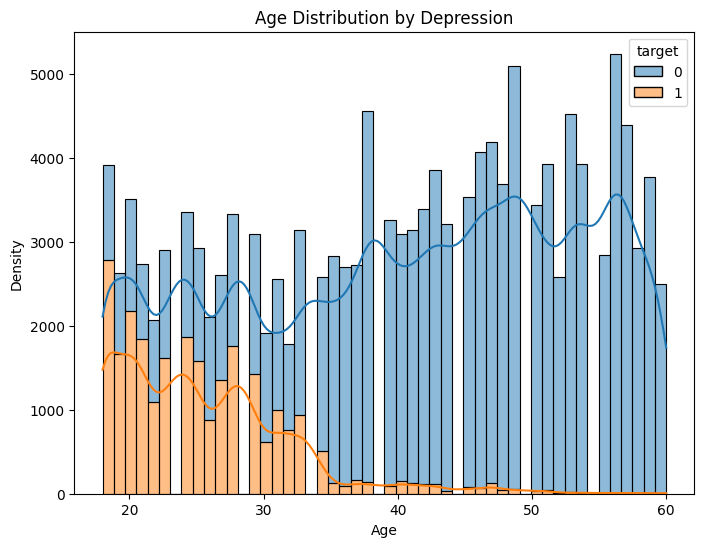

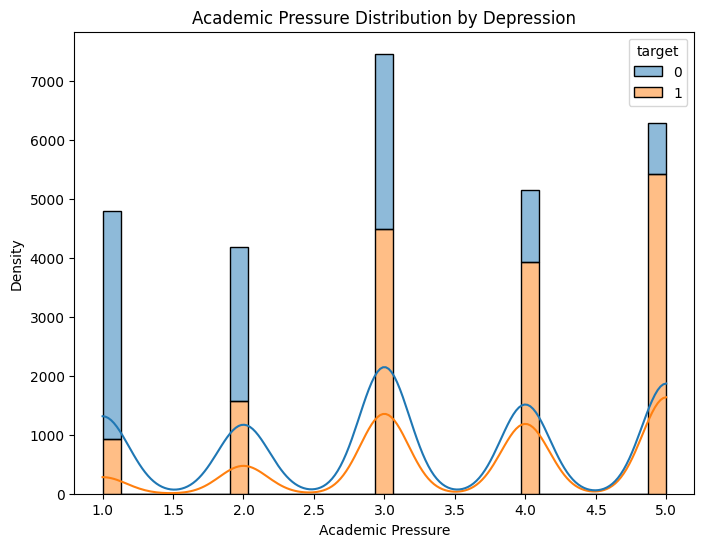

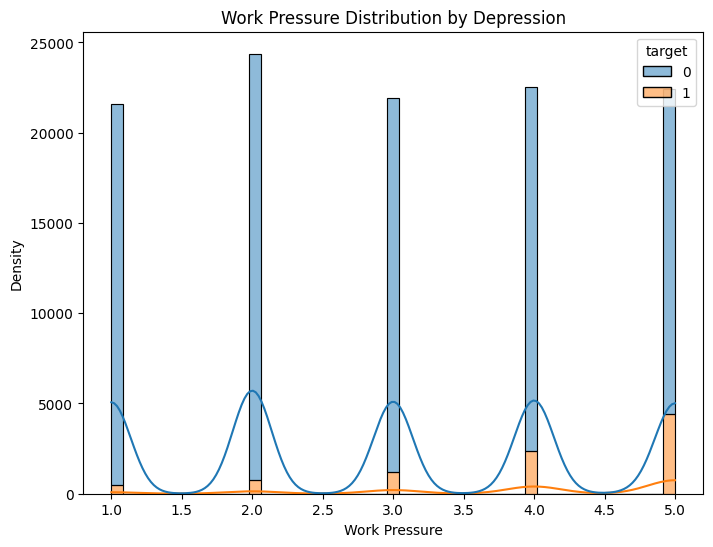

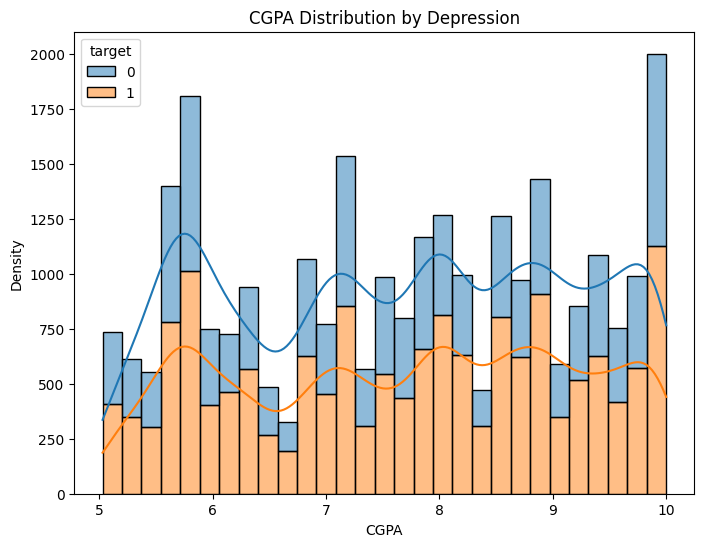

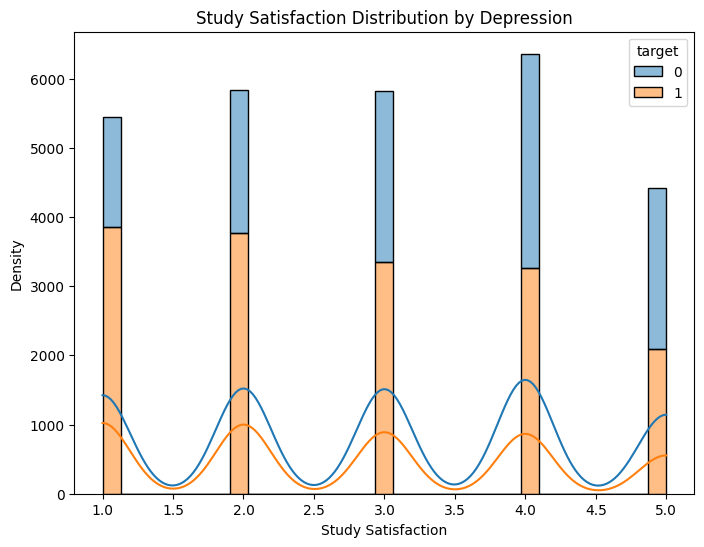

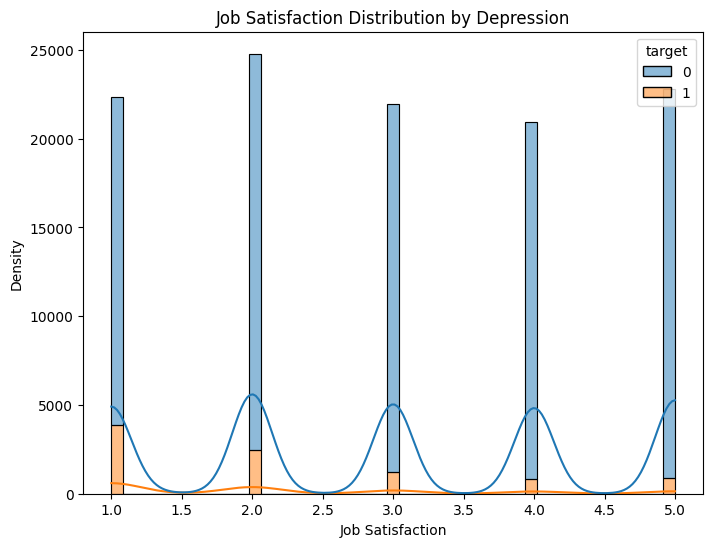

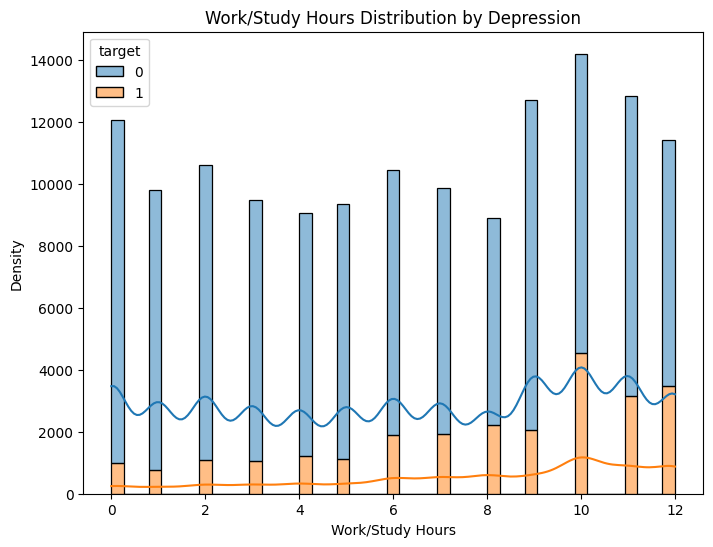

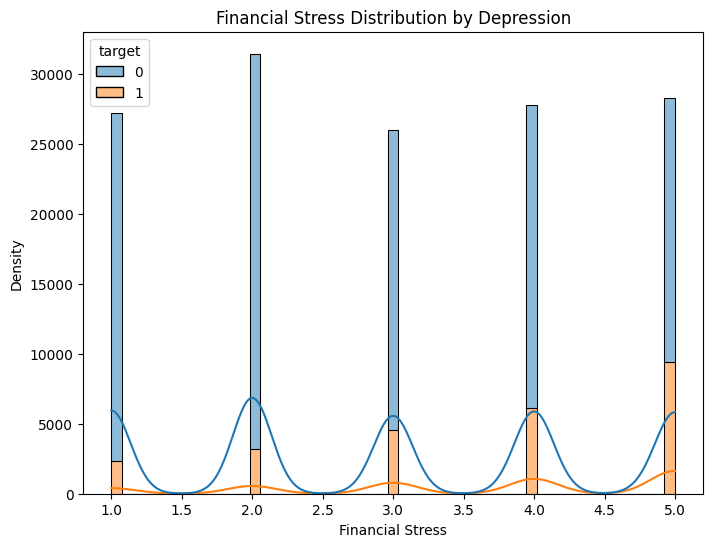

In [12]:
for col in num_cols:
    plot_num(df_train,col)

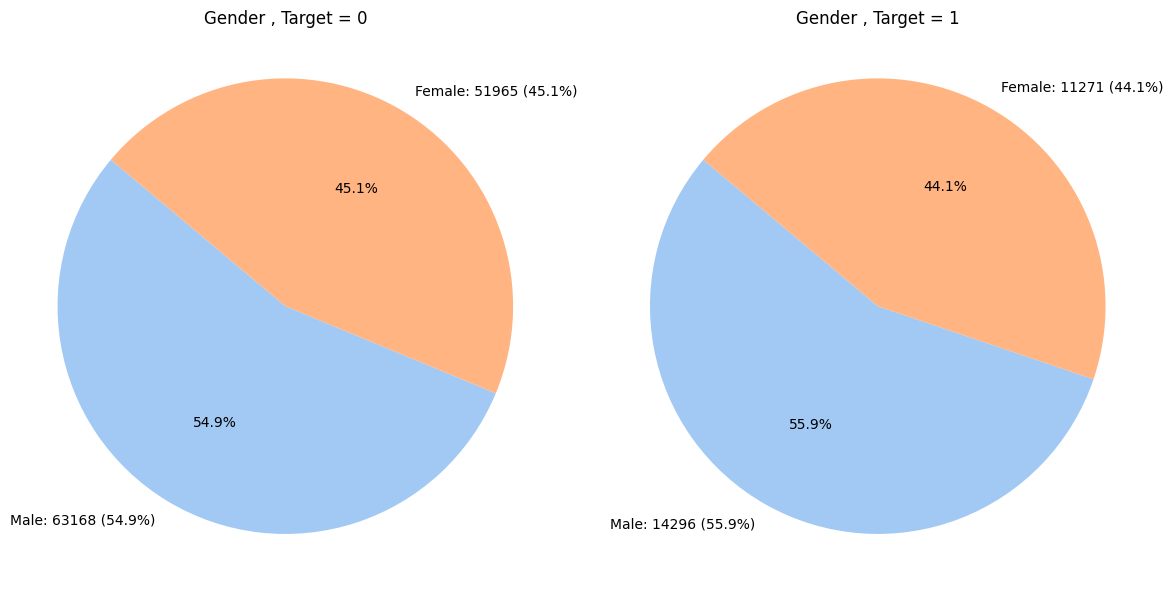

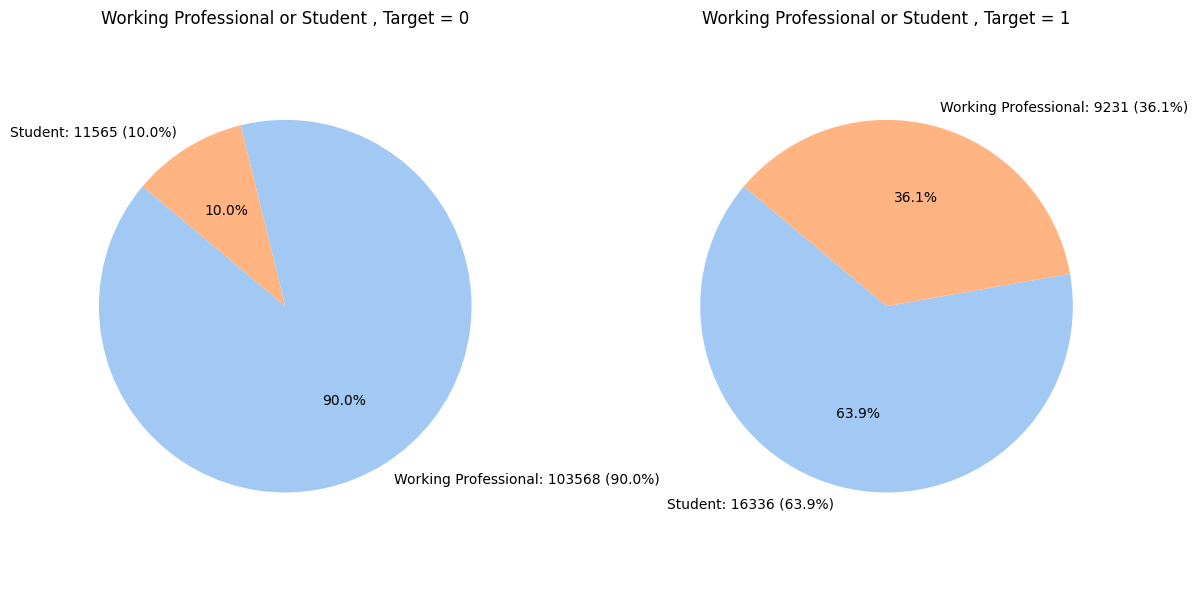

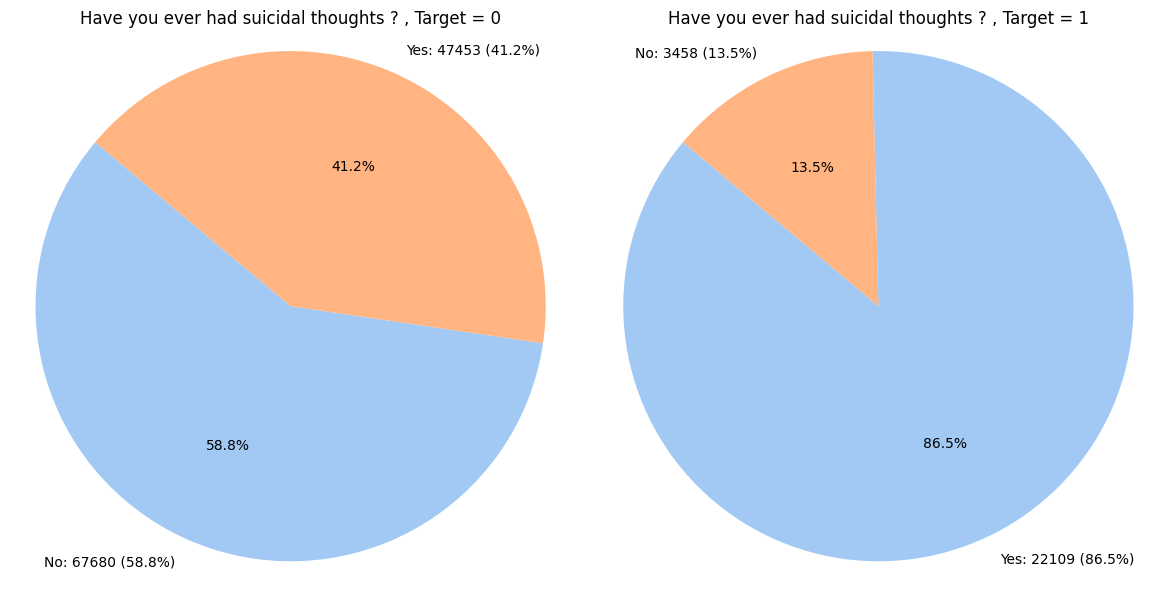

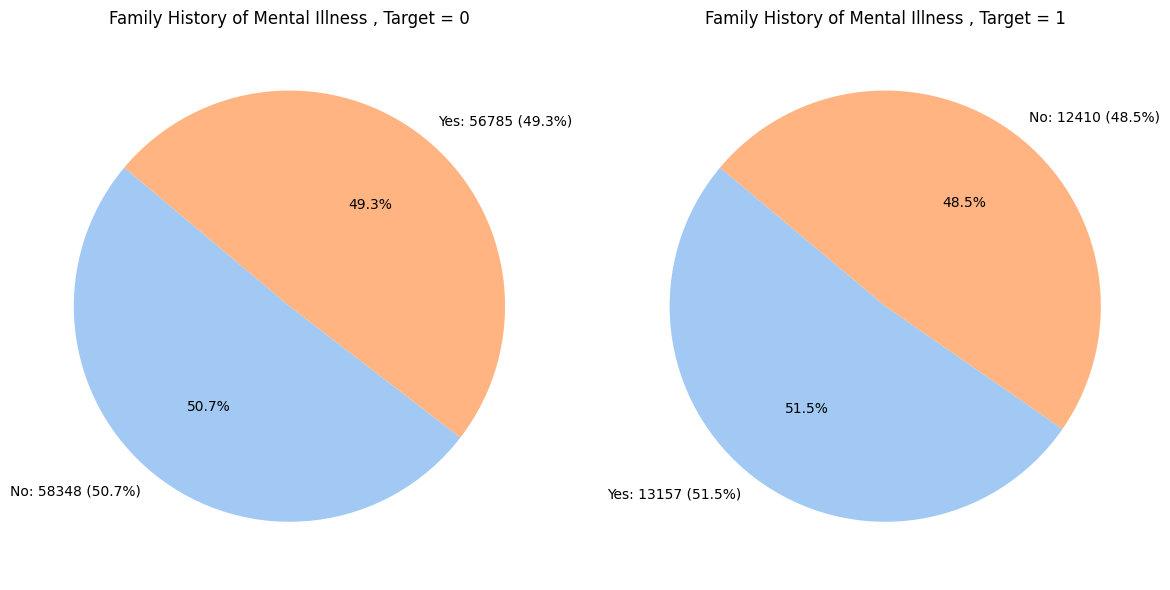

 
 Name == 422 unqiue values 
 
 
 City == 98 unqiue values 
 
 
 Profession == 64 unqiue values 
 
 
 Sleep Duration == 36 unqiue values 
 
 
 Dietary Habits == 23 unqiue values 
 
 
 Degree == 115 unqiue values 
 


In [13]:
def plot_cat(df,col):
    data_target = df_train[target_col]
    data_column = df_train[col]
    unique_values_count = data_column.nunique()

    data_df = pd.DataFrame({col: data_column, 'target': target_col})
    unique_values = df[col].dropna().unique()

    if unique_values_count == 2:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        for i, target_value in enumerate([0, 1]):
            value_counts = df[df[target_col] == target_value][col].value_counts()
            axes[i].pie(
                    value_counts, 
                    labels=[f'{idx}: {count} ({count / value_counts.sum() * 100:.1f}%)' for idx, count in value_counts.items()], 
                    autopct='%1.1f%%', 
                    startangle=140,
                    colors=sns.color_palette("pastel")[0:2]
            )
            axes[i].set_title(f'{col} , Target = {target_value}')
            axes[i].axis('equal')

        plt.tight_layout()
        plt.show()

    elif unique_values_count < 10:
        g = sns.FacetGrid(data_df, col=target_col, height=4, aspect=1.5, sharey=False)
        g.map(sns.countplot, col, palette="pastel", order=unique_values)
        g.set_axis_labels(col, 'Frequency')
        g.set_titles(col_template='Target = {col}')
        for ax in g.axes.flatten():
            ax.set_yscale('log')
        plt.show()
    else:
        return f" \n {col} == {len(df_train[col].value_counts())} unqiue values \n "
    
additional_info = []
for col in cat_cols:
    additional_info.append(plot_cat(df_train,col))
    
for info in additional_info:
    if info:
        print(info)

In [14]:
df_train['Sleep Duration'].value_counts()

Sleep Duration
Less than 5 hours    38784
7-8 hours            36969
More than 8 hours    32726
5-6 hours            32142
3-4 hours               12
6-7 hours                8
4-5 hours                7
2-3 hours                5
4-6 hours                5
6-8 hours                4
1-6 hours                4
No                       4
9-11 hours               2
10-11 hours              2
Sleep_Duration           2
Unhealthy                2
45                       2
8-9 hours                2
10-6 hours               1
9-5                      1
45-48 hours              1
3-6 hours                1
Work_Study_Hours         1
49 hours                 1
than 5 hours             1
Pune                     1
9-6 hours                1
8 hours                  1
35-36 hours              1
Indore                   1
1-3 hours                1
55-66 hours              1
Moderate                 1
40-45 hours              1
1-2 hours                1
9-5 hours                1
Name: count, 

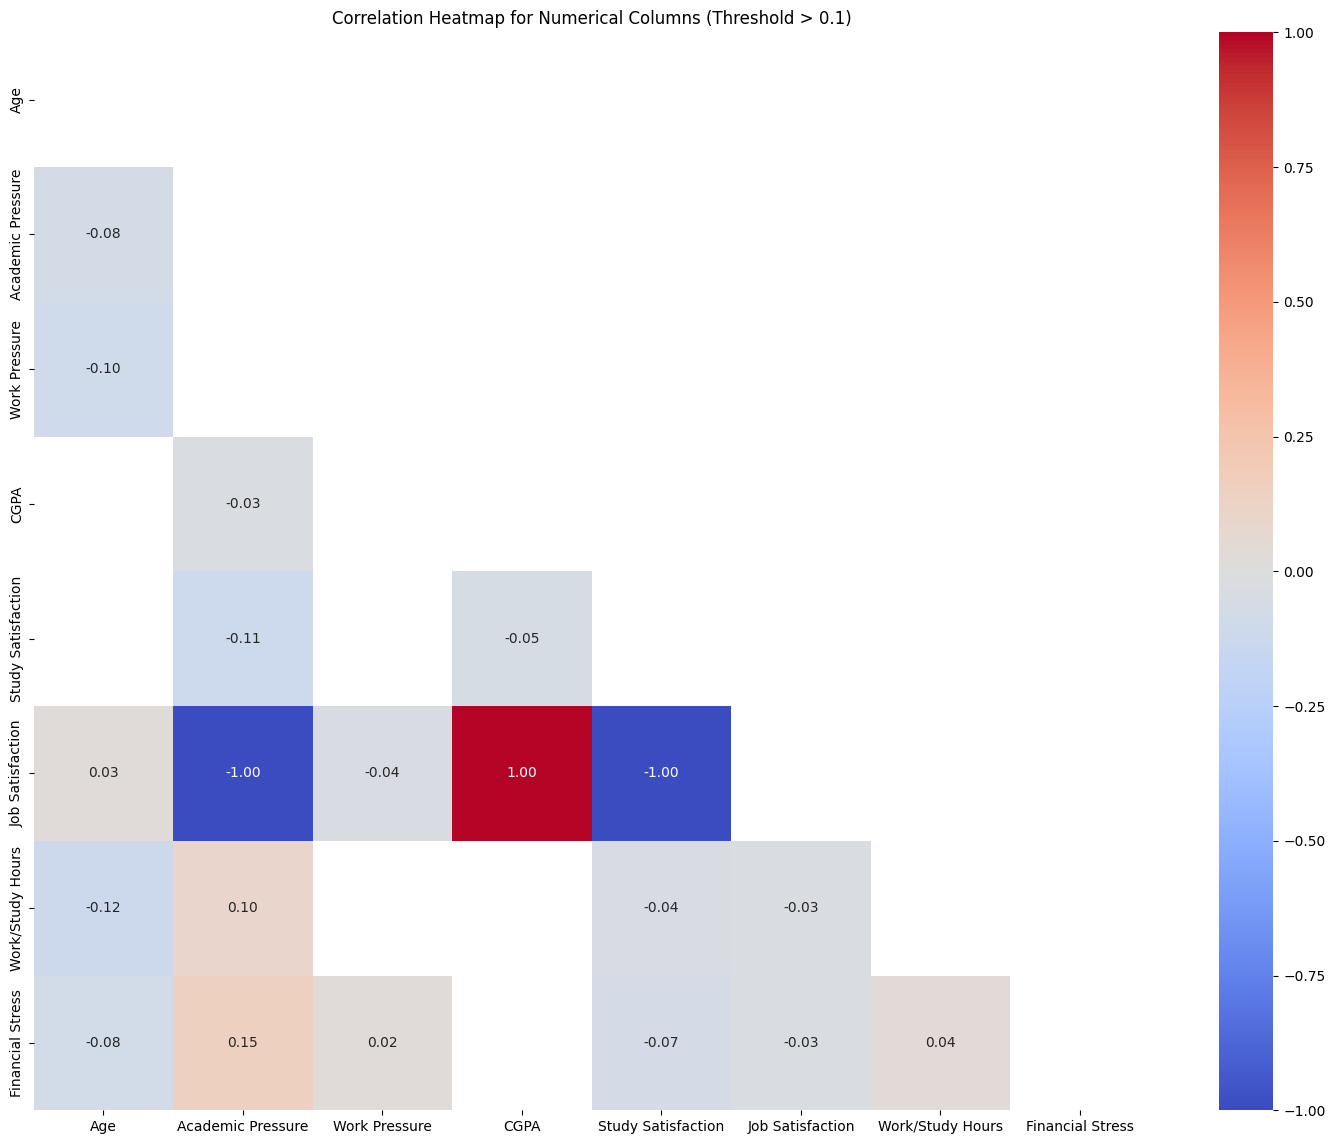

In [15]:
def plot_heatmap_num(df):
    num_data = df[num_cols]
    corr_matrix = num_data.corr()

    corr_matrix = corr_matrix.where(corr_matrix.abs() > 0.01)

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    plt.figure(figsize=(18, 14))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, mask=mask)
    plt.title('Correlation Heatmap for Numerical Columns (Threshold > 0.1)')
    plt.show()
    
plot_heatmap_num(df_train)

# **2.Data preprocessing**

In [16]:
one_hot_cols = [col for col in cat_cols if len(df_train[col].value_counts())==2]
ordinal_cols = [col for col in cat_cols if len(df_train[col].value_counts())!=2]


In [17]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer

ordinal_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant',fill_value='unkown')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))  
])

onehot_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant',fill_value='unkown')),
    ('ordinal', OneHotEncoder(handle_unknown='ignore'))  
])


numerical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant',fill_value=0)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipe, num_cols),
    ('cat_ordinal', ordinal_pipe, ordinal_cols),
    ('cat_onehot', onehot_pipe, one_hot_cols)
])

# **3.Model Training**

In [18]:
from sklearn.model_selection import train_test_split

X = df_train[num_cols+cat_cols]
y = df_train[target_col]
X_train,X_val,y_train,y_val = train_test_split(X,y, test_size=0.2, random_state=42)

In [19]:
model = XGBClassifier(seed=42)

In [20]:
pipe = Pipeline(steps=[('preprocessor',preprocessor),('model',model)])
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['Age', 'Academic Pressure',
                                                   'Work Pressure', 'CGPA',
                                                   'Study Satisfaction',
                                                   'Job Satisfaction',
                                                   'Work/Study Hours',
                                                   'Financial Stress']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unkown',
                                                                                 s...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

# **4.Model evaluation**

In [21]:
y_pred=pipe.predict(X_val)
score = accuracy_score(y_val,y_pred)
print(score)

0.9382018479033405


In [22]:
final_model = XGBClassifier(seed=42)
final_pipe = Pipeline(steps=[('preprocessor',preprocessor),('model',final_model)])
final_pipe.fit(X,y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['Age', 'Academic Pressure',
                                                   'Work Pressure', 'CGPA',
                                                   'Study Satisfaction',
                                                   'Job Satisfaction',
                                                   'Work/Study Hours',
                                                   'Financial Stress']),
                                                 ('cat_ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unkown',
                                                                                 s...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

In [23]:
df_test = pd.read_csv("/kaggle/input/playground-series-s4e11/test.csv")

ids = df_test.id

X_test = df_test.drop(['id'],axis=1)

test_preds = final_pipe.predict(X_test)
output = pd.DataFrame({'id': ids,
                       'Depression': test_preds})

result = output.to_csv('submission.csv', index=False)


In [24]:
output.head()

,id,Depression
0,140700,0
1,140701,0
2,140702,0
3,140703,1
4,140704,0
